# Co-occurrence outfit recommendation model

Basic Idea: items worn together frequently get recommended together

In [ ]:
#Install gdown, this lets colba download a shared google drive file
!pip install gdown

In [2]:
#Our libraries
from google.colab import drive #To access our google drives
from collections import defaultdict, Counter #Imports a special dictionary that automatically creates empty lists/dictionaries. (useful for grouping outfits)
import random  # Randomly samples outfits/items for testing and display
import pandas as pd #Works with the dataset as a dataframe
import gdown # Downloads the shared dataset from Google Drive
import os
from sklearn.model_selection import train_test_split #Using this to split the data into train/test sets
import matplotlib.pyplot as plt #These last four libraries are used to display the recommended outfits
from PIL import Image
import io
import ast

In [3]:
#Load to load the dataset, the dataset downloads only if it is not already saved in their Drive.
#Make sure to give access when it asks
from google.colab import drive
drive.mount('/content/drive')

file_id = "1D2co4zLvF30o41vYTl8o_KRrurFcGxl8"

url = f"https://drive.google.com/uc?id={file_id}"

# SAVE INSIDE GOOGLE DRIVE
output = "/content/drive/MyDrive/cleaned_polyvore.csv"

# Download only if it doesn't already exist
if not os.path.exists(output):
    gdown.download(url, output, quiet=False)

# Load dataset
df = pd.read_csv(output)

df.head()

Mounted at /content/drive


,image,category,text,item_ID,original_category,outfit_id
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Dress,tibi knit long sleeve dress,100002074_1,Day Dresses,100002074
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Shoes,michael kors leather over-the-knee boots,100002074_2,Boots,100002074
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Jacket,miranda coat,100002074_7,Coats,100002074
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Jacket,three pocket blazer,100010727_1,Blazers,100010727
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Jeans,givenchy skinny jean,100010727_2,Skinny Jeans,100010727


In [4]:
#I wrote the code with item_ID as item_id, so I'm just replacing it.+
df = df.rename(columns={"item_ID": "item_id"})

In [5]:
#Splitting the data into train + test sets
#We split by outfit_id, not by individual rows.
#This prevents items from the same outfit appearing in both train and test data.
outfit_ids = df["outfit_id"].unique() #Splitting by outfit ID

train_ids, test_ids = train_test_split( #This step splits our data
    outfit_ids,
    test_size=0.2,
    random_state= 42
)

train_df = df[df["outfit_id"].isin(train_ids)] #Save the train dataset, used to teach catergory relationships
test_df = df[df["outfit_id"].isin(test_ids)]   #Save the test data, used to evaluate the model (By if the model can y predict the missing clothing items from an outfit?”)

In [6]:
#Build train outfit
#outfit_id -> list of items
outfits = defaultdict(list) #This creates empty lists for each outfit. Which we will fill in with clothing itesm (Clothing ID)

for _, row in train_df.iterrows(): #loops through every item in our train dataset and groups together outfits
    outfits[row["outfit_id"]].append({
        "item_id": row["item_id"],    #item Id label
        "category": row["category"],  #category label
        "text": row["text"]          # text label
    })

#This groups rows back into full outfits so the model can learn what clothing items belong together.

In [7]:
#BUILD CO-OCCURRENCE MAP
#This is the main learning step.
#item -> related
#The main idea is that over time, the model learns relationships like:  shirt + jeans, dress + shoes, shirt +pants, etc.
#Logistically: The model counts how often categories appear together in the same outfit.
#Example:
#If Dress and Shoes appear together often, then:
#co_occurrence["Dress"]["Shoes"] becomes large.

co_occurrence = defaultdict(Counter)

for outfit_items in outfits.values():
  #Get only the category labels for every item in the outfit.
   categories = [x["category"] for x in outfit_items]

 #Count every category pair inside the outfit.
   for item in categories:
       for other in categories:
           if item != other:
               co_occurrence[item][other] += 1

#Example: show what categories are commonly paired with Jeans.
print("Categories commonly paired with Jeans:")
print(co_occurrence["Jeans"].most_common(5))
print("Categories commonly paired with Dress:")
print(co_occurrence["Dress"].most_common(5))


Categories commonly paired with Jeans:
[('Shoes', 1338), ('Shirt', 1330), ('Jacket', 716), ('Tank Top', 202), ('Hoodie', 45)]
Categories commonly paired with Dress:
[('Shoes', 2307), ('Jacket', 827), ('Shirt', 180), ('Skirt', 42), ('Jeans', 30)]


In [8]:
# RECOMMENDATION FUNCTION
#Input:categories (Items) the user already has, like "Jeans"
#Output:categories (Items) that often appear with those inputs, like "Shirt", "Shoes", "Jackets"

def recommend_category(input_categories, top_k=5):
    scores = Counter()

#Add up co-occurrence scores for each input category.
    for category in input_categories:
        if category in co_occurrence:
            scores.update(co_occurrence[category])

#Do not recommend something the user already provided.
    for category in input_categories:
        scores.pop(category, None)
#Return the highest scoring category recommendations.
    return scores.most_common(top_k)

In [9]:
#This part picks real items images from the dataset
#The model predicts categories, but we want images.
#This function takes predicted categories and chooses REAL clothing items/images from the dataset. (So if it predicts a shirt, it will find a random shirt image from the dataset)
def recommend_items_from_categories(predicted_categories, df, n_per_category=1):
    rec_items = []

    for category, score in predicted_categories:
       #Find all items in the dataset with this category (Ex. find all the shirts)
        candidates = df[df["category"] == category]

       #Randomly choose example items from that category. (Ex, choose. random shirt from all the shirts)
        if len(candidates) > 0:
            item = candidates.sample(1).iloc[0]
            rec_items.append(item)

    return rec_items

In [10]:
#BUILD COMPLETE OUTFIT, this step is where the model actually builds a outfit
# Example:
# User enters "Jeans"
# Model fills in missing outfit slots:
# Shirt + Shoes + Jackets, using what it's learned from above
def build_complete_outfit(input_categories, df, top_k=3):

    recommendations = recommend_category(input_categories, top_k=top_k)

    complete_items = []

    for category, score in recommendations:

        candidates = df[df["category"] == category]
        if len(candidates) > 0:
            item = candidates.sample(1).iloc[0]
            complete_items.append(item)

    return complete_items

In [11]:
#This is to DISPLAY THE RECOMMENDED OUTFIT
#The image column is stored as a string version of a dictionary.
#ast.literal_eval converts it back into a Python dictionary so we can access image bytes.
def show_recommendations(rec_items):

    for item in rec_items:
        #Convert image string back into dictionary
        image_dict = ast.literal_eval(item["image"])

        image_data = image_dict["bytes"]

        img = Image.open(io.BytesIO(image_data))

        #Display image.
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis("off")

        # Top text
        plt.title(
            f'{item["category"]}\n'
            f'{item["text"]}',
            fontsize=10
        )

        # Bottom text
        plt.figtext(
            0.5,
            0.01,
            f'Item ID: {item["item_id"]}\n'
            f'Outfit ID: {item["outfit_id"]}',
            ha= 'center',
            fontsize=9
        )

        plt.show()

In [12]:
#Build test outfits (We did this earlier but that was for training the model)
#This groups the test dataframe into complete outfits.
#We use this only for evaluating.
#Why? If you evaluated using training outfits: the model would already know the answers

test_outfits = defaultdict(list)

for _, row in test_df.iterrows():
    test_outfits[row["outfit_id"]].append({
        "item_id": row["item_id"],
        "category": row["category"],
        "text": row["text"]
    })

print("Number of testing outfits:", len(test_outfits))

Number of testing outfits: 2820


In [13]:
#EVALUATION
#The model is evaluated by hiding one category from each test outfit.
#Example:
#Original outfit: ["Jeans", "Shirt", "Shoes"]
#Hidden category: "Shoes"
#Input categories: ["Jeans", "Shirt"]
#The model is correct if "Shoes" appears in its top 3 recommendations.

correct = 0
total = 0

for outfit_items in test_outfits.values():
    #Skip outfits with fewer than 2 items
    if len(outfit_items) < 2:
        continue
    #Randomly hide one item from the outfit.
    hidden_item = random.choice(outfit_items)

    #Use the remaining item categories as input.
    input_categories = [
        x["category"]
        for x in outfit_items
        if x["item_id"] != hidden_item["item_id"]
    ]

    #Predict likely missing categories.
    recommendations = recommend_category(input_categories, top_k=3) #You can change the top k to see how the accuracy chnanges

    #Extract only the category names from the results.
    recommended_categories = [x[0] for x in recommendations]

    #Count as correct if the hidden category appears in the top 5.
    if hidden_item["category"] in recommended_categories:
        correct += 1

    total += 1

accuracy = correct / total if total > 0 else 0
print(f"Top-3 Category Accuracy: {accuracy:.2%}")

Top-3 Category Accuracy: 79.65%


#Now, we're making it interative

Enter a starting category (Shoes, Shirt, Jacket, Dress, Skirt, Jeans, Pants, Shorts, Tank Top, Hoodie, Suits): Jeans
Starting category: ['Jeans']
Number of recommendations: 3


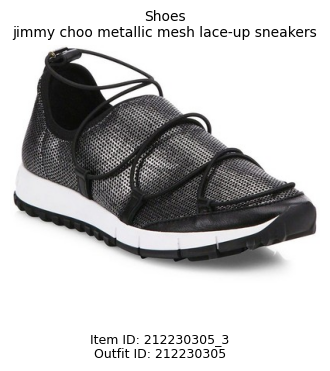

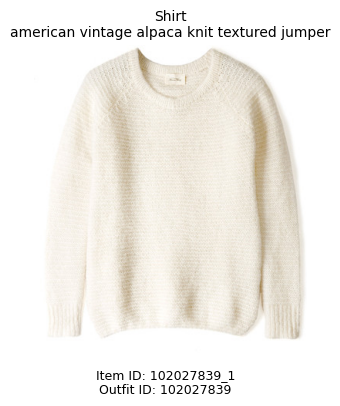

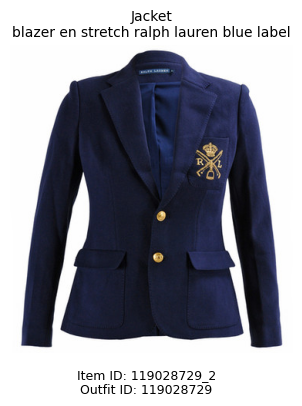

In [21]:
#USER INPUT DEMO
#This lets a user type a starting category and get outfit image recommendations.
#The outfits are bad because the model is only learning categories and choosing at random. Ex. a shirt can be worn with shoes, pants, jeans, jacket etc.
category_aliases = {
    "Dress": "Dress",
    "Dresses": "Dress",
    "Jean": "Jeans",
    "Jeans": "Jeans",
    "Pant": "Pants",
    "Pants": "Pants",
    "Shoe": "Shoes",
    "Shoes": "Shoes",
    "Jacket": "Jackets",
    "Jackets": "Jackets",
    "Skirt": "Skirts",
    "Skirts": "Skirts",
    "Shirt": "Shirt",
    "Hoodie": "Shirt",
    "Tank": "Tank Top",
    "Tank Top": "Tank Top",
    "Short": "Shorts",
    "Shorts": "Shorts",
    "Suit": "Suits",
    "Suits": "Suits"
}
user_category = input("Enter a starting category (Shoes, Shirt, Jacket, Dress, Skirt, Jeans, Pants, Shorts, Tank Top, Hoodie, Suits): ").strip().title()

user_category = category_aliases.get(user_category, user_category)

input_categories = [user_category]

print("Starting category:", input_categories)

recommended_items = build_complete_outfit(input_categories, df, top_k=3)

print("Number of recommendations:", len(recommended_items))

if len(recommended_items) == 0:
    print("No recommendations found.")
    print("Available categories:")
    print(sorted(df["category"].unique()))
else:
    show_recommendations(recommended_items)